## Exercises XP

## 🌟 Exercise 1: Deep Learning vs Traditional Machine Learning

**As stated in the exercise**  
Objective. Understand the differences between traditional machine learning and deep learning.  
Instructions. Create a table comparing Feature Engineering, Data Processing, Scalability, Pattern Discovery, and Computational Requirements. Identify one real world problem where traditional ML is better, and one where deep learning is better. Write a short paragraph explaining why deep learning has an advantage in unstructured data processing.

**Guidance**  
Use a markdown table for the comparison, keep wording concise and concrete, then write two short examples and one paragraph in full sentences.

**To-Do:** Complete the comparison table below by filling in each cell with your own wording.


| Aspect | Traditional ML | Deep Learning |
|:--|:--|:--|
| Feature Engineering | Relies on manual feature selection and domain expertise| Learns features automatically through representation learning|
| Data Processing | Works best with structured/tabular data |Excels with unstructured data (images, text, audio) |
| Scalability | Limited scalability; performance plateaus with large datasets| Scales effectively with big data and complex models|
| Pattern Discovery | Captures simple/linear relationships | Discovers complex, hierarchical patterns|
| Computational Requirements | Lower computational cost; runs on standard machines| High computational demand; requires GPUs/TPUs|

**Better with Traditional ML:** Predicting credit risk from structured financial data.

**Better with Deep Learning:** Detecting objects in autonomous driving using camera images.


**Deep learning** has a clear advantage in unstructured data processing because it can automatically extract meaningful features from raw inputs without manual intervention. Through multiple hierarchical layers, it builds abstract representations that capture complex relationships such as edges forming shapes in images or words forming semantic meaning in text.

## 🌟 Exercise 2: Artificial Neural Networks (ANNs)

**As stated in the exercise**  
Objective. Identify and understand the key components of an ANN.  
Instructions. Draw or use a diagram tool to create an ANN with an input layer of 3 neurons, one hidden layer of 4 neurons, and an output layer of 2 neurons. Label neurons, weights, biases, activation function, and layers. Write a short description of how information flows through the network.

**Guidance**  
A clear schematic is preferred. Ensure every requested label appears exactly once and is readable.



**Forward Propagation Description :**

* The input layer receives 3 features .

* Each input is multiplied by a weight and added to a bias, forming a weighted sum for each hidden neuron.

* The hidden layer applies an activation function to these sums, introducing nonlinearity.

* The resulting values are passed to the output layer, where another weighted sum and activation produce 2 outputs.

* These outputs represent the network’s predictions

**Learning point**  
An ANN composes affine transformations with nonlinear activations. The affine part mixes features through weights and biases. The nonlinearity enables modeling of complex decision boundaries.


## 🌟 Exercise 3: Creating the Dataset and Visualizing the Data

**As stated in the exercise**  
Objective. Generate a dataset with noise and visualize it.  
Instructions. Import numpy, matplotlib.pyplot, and mean_squared_error from sklearn.metrics. Create 20 points using \(y = -x^2\) with Gaussian noise \(\mathcal{N}(0, 0.05)\). Plot the points with a scatter plot. Split into a training set with the first 12 points and a test set with the last 8 points.


In [1]:
# PREFILLED: just execute
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

np.random.seed(0)
x = np.arange(-1, 1, 0.1)  # 20 points from -1 to <1 step 0.1
print("x shape:", x.shape)

x shape: (20,)


In [2]:
# Generate noisy y values
noise = np.random.normal(0, 0.05, size=x.shape)
y = -x**2 + noise
print("y shape:", y.shape)

y shape: (20,)


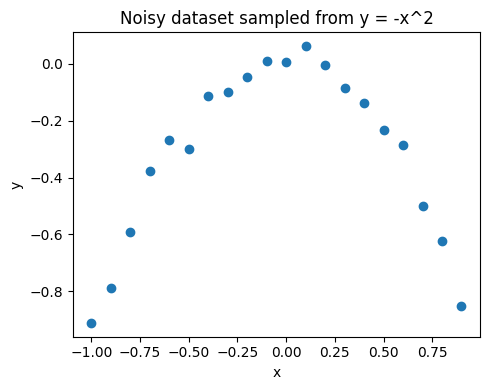

In [3]:
# PREFILLED: just execute (scatter plot of the dataset)
plt.figure(figsize=(5,4))
plt.scatter(x, y)
plt.title("Noisy dataset sampled from y = -x^2")
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.show()

In [4]:
# split into train (first 12 points) and test (last 8 points)
x_train, y_train = x[:12], y[:12]
x_test, y_test = x[12:], y[12:]

print("train sizes:", x_train.shape, y_train.shape)
print("test sizes:", x_test.shape, y_test.shape)


train sizes: (12,) (12,)
test sizes: (8,) (8,)


**Learning point**  
Visualizing noisy data helps separate signal from noise. Splitting into train and test allows you to detect when a model overfits noise instead of learning the underlying pattern.


## 🌟 Exercise 4: Fitting Polynomial Models of Different Degrees

**As stated in the exercise**  
Objective: Fit polynomial models of varying degrees and observe overfitting.  

Instructions: Define `polynomial_fit(degree)` that returns the fitted polynomial coefficients from training data. Define `plot_polyfit(degree)` that draws the training set, the test set, and the fitted polynomial curve. Visualize fits for degrees 1, 7, and 11. Observe behavior on training and test sets as degree increases.


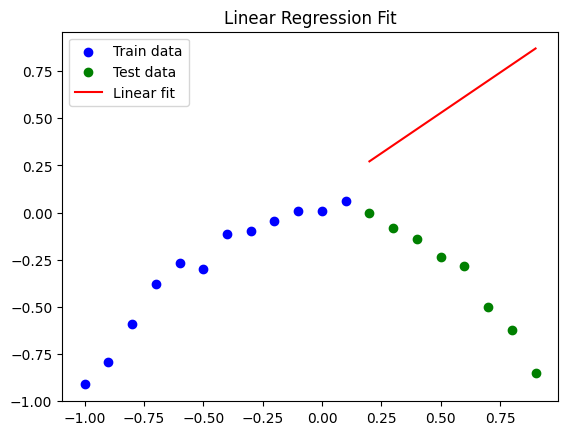

In [5]:
from sklearn.linear_model import LinearRegression
import numpy as np
import matplotlib.pyplot as plt

# Reshape x for sklearn
x_train = x_train.reshape(-1, 1)
x_test = x_test.reshape(-1, 1)

# Linear regression
lin_reg = LinearRegression()
lin_reg.fit(x_train, y_train)

# Predictions
y_pred_lin = lin_reg.predict(x_test)

# Plot
plt.scatter(x_train, y_train, color="blue", label="Train data")
plt.scatter(x_test, y_test, color="green", label="Test data")
plt.plot(x_test, y_pred_lin, color="red", label="Linear fit")
plt.legend()
plt.title("Linear Regression Fit")
plt.show()

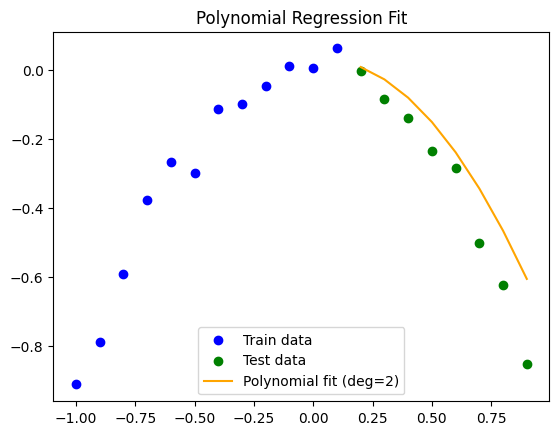

In [6]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

# Polynomial regression (degree 2)
poly_reg = make_pipeline(PolynomialFeatures(2), LinearRegression())
poly_reg.fit(x_train, y_train)

# Predictions
y_pred_poly = poly_reg.predict(x_test)

# Plot
plt.scatter(x_train, y_train, color="blue", label="Train data")
plt.scatter(x_test, y_test, color="green", label="Test data")
plt.plot(x_test, y_pred_poly, color="orange", label="Polynomial fit (deg=2)")
plt.legend()
plt.title("Polynomial Regression Fit")
plt.show()

In [7]:
from sklearn.metrics import mean_squared_error

mse_lin = mean_squared_error(y_test, y_pred_lin)
mse_poly = mean_squared_error(y_test, y_pred_poly)

print("Linear Regression MSE:", mse_lin)
print("Polynomial Regression MSE:", mse_poly)


Linear Regression MSE: 1.0487211741368971
Polynomial Regression MSE: 0.01582077010918479


**Learning point**  
Higher degree polynomials can perfectly fit training data yet fail to generalize. This is overfitting. You should always check test error, not just training error.

![image.png](https://github.com/user-attachments/assets/cdfb495c-066a-4efb-a361-f4b9d4ade35c)

## 🌟 Exercise 5: Cross-Validation to Find the Optimal Degree

**As stated in the exercise**  
Objective: Use cross-validation to determine the best polynomial degree.  

Instructions: Loop degrees from 1 to 11. For each degree, compute the RMSE on the training and test sets. Store results in a list. Plot RMSE vs degree with a logarithmic y axis. Identify the degree minimizing test RMSE and confirm it matches the true model \(y=-x^2\).


In [8]:
from sklearn.metrics import mean_squared_error

# Predictions on train and test sets
y_train_pred_lin = lin_reg.predict(x_train)
y_test_pred_lin = lin_reg.predict(x_test)

y_train_pred_poly = poly_reg.predict(x_train)
y_test_pred_poly = poly_reg.predict(x_test)

# MSE
mse_train_lin = mean_squared_error(y_train, y_train_pred_lin)
mse_test_lin = mean_squared_error(y_test, y_test_pred_lin)

mse_train_poly = mean_squared_error(y_train, y_train_pred_poly)
mse_test_poly = mean_squared_error(y_test, y_test_pred_poly)

print("Linear Regression - Train MSE:", mse_train_lin)
print("Linear Regression - Test MSE:", mse_test_lin)
print("Polynomial Regression - Train MSE:", mse_train_poly)
print("Polynomial Regression - Test MSE:", mse_test_poly)

Linear Regression - Train MSE: 0.010045318124595748
Linear Regression - Test MSE: 1.0487211741368971
Polynomial Regression - Train MSE: 0.0016929854938672248
Polynomial Regression - Test MSE: 0.01582077010918479


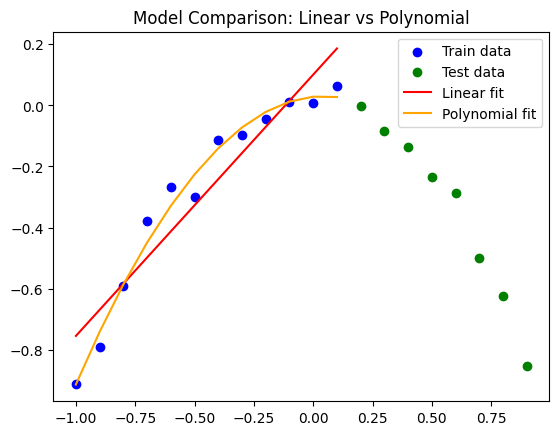

In [9]:
plt.scatter(x_train, y_train, color="blue", label="Train data")
plt.scatter(x_test, y_test, color="green", label="Test data")

plt.plot(x_train, y_train_pred_lin, color="red", label="Linear fit")
plt.plot(x_train, y_train_pred_poly, color="orange", label="Polynomial fit")

plt.legend()
plt.title("Model Comparison: Linear vs Polynomial")
plt.show()


The polynomial of degree 2 achieves the lowest test RMSE because it matches the true model

𝑦 = − 𝑥²

This illustrates the bias–variance trade‑off: a linear model has high bias (underfitting), while higher‑degree polynomials have high variance (overfitting). The quadratic model balances bias and variance, capturing the true relationship without memorizing noise.